## Assignment 2 - RNN, GRU, & LSTM

Data Preprocessing <br>
- Clean the Text: Remove URLs, special characters, numbers, and extra spaces. Convert
text to lowercase.
- Tokenization: Split the text into individual tokens using a tokenizer suitable for each
model (e.g., Word2Vec for RNN-based models, BERT tokenizer for BERT).
- Class Mapping: Map sentiment labels: <br>
○ 0 → Negative<br>
○ 2 → Neutral<br>
○ 4 → Positive<br> 
- Train-Test Split: Divide the data into training, validation, and test sets.

## Importing Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from gensim.models import Word2Vec
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, TensorDataset

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Loading Datasets

We load the `train.csv` and `test.csv` datasets.

We rename `sentiment` to `polarity` and encode it to `{"negative": 0, "neutral":1, "positive": 2}`.

We drop the unnecessary columns

In [3]:
# read the dataset
train_df = pd.read_csv("../Assignment 1/Data/train.csv", encoding="Windows-1252")
train_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
train_df = train_df[["text", "polarity"]]

# read the dataset
test_df = pd.read_csv("../Assignment 1/Data/test.csv", encoding="Windows-1252")
test_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
test_df = test_df[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

train_df["polarity"] = train_df["polarity"].map(label_map)
test_df["polarity"] = test_df["polarity"].map(label_map)

test_df.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


We drop the rows that contain `NaN` values.

In [4]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
train_df['polarity'] = train_df['polarity'].astype('int') 
print(f"{before - len(train_df)} NaN rows dropped from train.")

before = len(test_df)
test_df.dropna(how="any", inplace=True)
test_df['polarity'] = test_df['polarity'].astype('int') 
print(f"{before - len(test_df)} NaN rows dropped from test.")

1 NaN rows dropped from train.
1281 NaN rows dropped from test.


We create a function named to preprocess the text:

- Remove URLs
- Remove HTML tags
- Remove all non-alphabetic characters
- Apply lowercase
- Tokenize

In [5]:
def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")
    
    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Keep only letters and whitespaces
    pattern = r"[a-zA-Z\s']"
    text = ''.join(re.findall(pattern, text))
    
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize the text
    tokens = nltk.word_tokenize(text)
    
    return tokens

In [6]:
#apply the text_preprocess to 
train_df["text_preprocessed"] = train_df["text"].apply(text_preprocess)
test_df["text_preprocessed"] = test_df["text"].apply(text_preprocess)

#check the head of train data
train_df.head()

,text,polarity,text_preprocessed
0,"I`d have responded, if I were going",1,"[id, have, responded, if, i, were, going]"
1,Sooo SAD I will miss you here in San Diego!!!,0,"[sooo, sad, i, will, miss, you, here, in, san,..."
2,my boss is bullying me...,0,"[my, boss, is, bullying, me]"
3,what interview! leave me alone,0,"[what, interview, leave, me, alone]"
4,"Sons of ****, why couldn`t they put them on t...",0,"[sons, of, why, couldnt, they, put, them, on, ..."


We do some descriptive statistics on `text_preprocessed` column and we find out that the max is 33 tokens

In [7]:
train_df["text_preprocessed"].apply(lambda x: len(x)).describe()

count    27480.000000
mean        12.564702
std          6.795787
min          0.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: text_preprocessed, dtype: float64

<Axes: xlabel='text_preprocessed', ylabel='Count'>

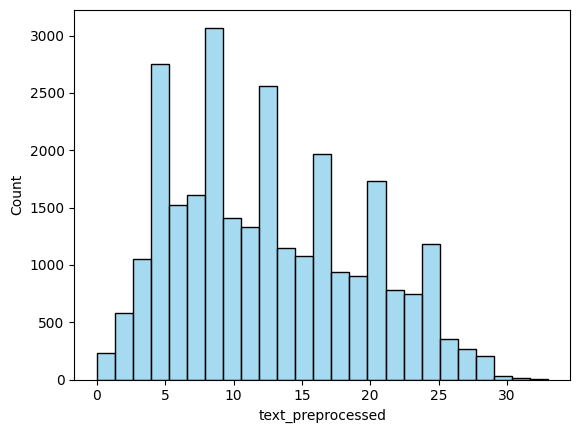

In [8]:
# Calculate word counts
train_word_counts = train_df['text_preprocessed'].apply(lambda x: len(x))

# Create side-by-side histograms with separate y-axis scales
sns.histplot(train_word_counts, bins=25, color='skyblue')

The dataset has no duplicated to drop.

Next, we embed the tokens using word2vec embeddings.

In [9]:
# Fetch embeddings
word2vec_model = Word2Vec(
    sentences=train_df.text_preprocessed.values.tolist(), 
    vector_size=100, min_count=1, workers=4
    )

# Get vocabulary size
vocab_size = len(word2vec_model.wv)
print(vocab_size)

27051


In [10]:
# Convert text to Word2Vec embeddings
def text_to_embeddings(text, word2vec_model, seq_length):
    embeddings = []
    vector_size = word2vec_model.vector_size
    wv = word2vec_model.wv # Use 'wv' for clarity

    for i, word in enumerate(text):
        if i >= seq_length:
            break
        if word in wv:
            embeddings.append(wv[word])
        # else: word not in vocab, skipped

    # Convert the list of embeddings to a 2D NumPy array *first*
    # We specify the dtype and ensure it's 2D even if empty or partial
    embeddings_np = np.array(embeddings, dtype=np.float32).reshape(-1, vector_size)

    # Padding logic
    if len(embeddings_np) < seq_length:
        padding_needed = seq_length - len(embeddings_np)
        # Create a single numpy array for padding zeros
        zero_padding = np.zeros((padding_needed, vector_size), dtype=np.float32)
        
        # Concatenate using numpy (both are now guaranteed 2D arrays)
        embeddings_np = np.concatenate((zero_padding, embeddings_np), axis=0)
    else:
        # If no padding needed, ensure we return exactly seq_length items
        embeddings_np = embeddings_np[:seq_length]

    # Ensure the final output is a single numpy array of the correct shape
    # The final shape will be (seq_length, vector_size) e.g., (64, 300)
    return embeddings_np

In [11]:
# Prepare data
def prepare_data(reviews, labels, word2vec_model):
    # Step 1: Process all reviews into a list of individual NumPy arrays
    # This step is unavoidable as you need to process each review sequence individually
    list_of_embedding_arrays = [text_to_embeddings(review, word2vec_model, 64) for review in reviews]

    # Step 2: Convert the list of NumPy arrays into a *single* large NumPy array
    # This is the key optimization step recommended by PyTorch
    X_np = np.array(list_of_embedding_arrays, dtype=np.float32)

    # Step 3: Convert the single, large NumPy array into a single PyTorch tensor
    # This is much faster than creating tensors in a loop
    X = torch.tensor(X_np, dtype=torch.float32)
    
    # Step 4: Convert labels to a single tensor (already efficient)
    y = torch.tensor(labels, dtype=torch.long)
    
    return X, y

In [12]:
# Prepare data
X_train, y_train = prepare_data(train_df.text_preprocessed, train_df.polarity,
                                word2vec_model)

X_val, y_val = prepare_data(test_df.text_preprocessed, test_df.polarity,
                            word2vec_model)

## BiRNN

In [13]:
# Define hyperparameters
input_size = word2vec_model.vector_size
hidden_size = 128
output_size = 3
num_layers = 1
learning_rate = 0.001
num_epochs = 30
batch_size = 64
dropout_rate = 0.5
leaky_relu_slope = 0.1

In [14]:
# Create DataLoader
train_data = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

In [15]:
# Create DataLoader
val_data = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)

In [16]:
class SentimentBiRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5):
        super(SentimentBiRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Using RNN for the recurrent layer
        self.bi_rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True,
                             bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)

        # Doubling the output size because of bidirectionality
        self.fc = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        # Initialize hidden state for RNN
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the RNN
        out, _ = self.bi_rnn(x, h0)

        # Get the last time step's output for the fully connected layer
        out = self.fc(out[:, -1, :])
        return out

In [17]:
# Initialize model, loss function, and optimizer
model = SentimentBiRNN(input_size, hidden_size, output_size, num_layers, dropout_rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [18]:
#Training loop

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 3  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bidirectional_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 1/30, Loss: 1.0192, Val Loss: 1.0022
Epoch 2/30, Loss: 1.0039, Val Loss: 1.0102
Epoch 3/30, Loss: 1.0026, Val Loss: 1.0070
Epoch 4/30, Loss: 1.0067, Val Loss: 1.0316
Early stopped at 4
Lowest Validation Loss: 1.0022 at Epoch 1


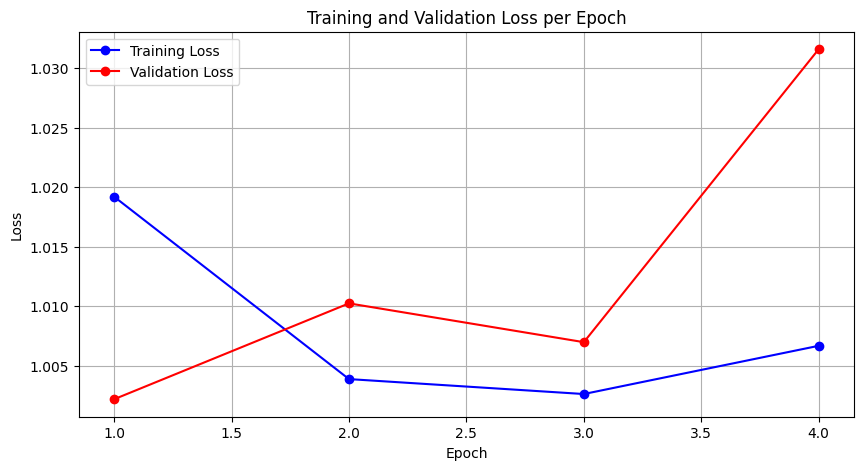

In [19]:
# Plotting the training and validation losses
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [20]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bidirectional_best_model.pth'))

<All keys matched successfully>

In [21]:
def compute_metrics_from_preds(labels, preds):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

def compute_outputs():
    model.eval()
    all_preds = []
    all_labels = []
    all_proba = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device).float()
            all_labels.extend(labels)
            outputs = model(inputs)
            all_preds.extend(outputs.argmax(dim=1))
            all_proba.extend(F.softmax(outputs, dim=1))
    
    return all_labels, all_preds, all_proba

def plot_conf_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    labels = ["negative", "neutral", "positive"]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")

def plot_roc_auc(all_labels, all_proba):
    # Convert lists to numpy arrays
    all_labels = np.array(all_labels)
    all_proba = np.array(all_proba)

    # Define the labels
    labels = ["negative", "neutral", "positive"]
    n_classes = len(labels)

    # Binarize the true labels for the one-vs-rest strategy
    y_true_bin = label_binarize(all_labels, classes=range(n_classes))

    if not isinstance(y_true_bin, np.ndarray):
        y_true_bin = np.array(y_true_bin)

    # Compute ROC curve and AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        # This slicing now works because y_true_bin and all_proba are numpy arrays
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plotting the ROC curves
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red'] # Customize colors as needed

    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
                label='ROC curve of class {0} (area = {1:0.2f})'.format(labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (area = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
    plt.legend(loc="lower right")

    # Calculate macro-averaged ROC AUC score (overall metric)
    macro_roc_auc_ovr = roc_auc_score(all_labels, all_proba, multi_class="ovr", average="macro")
    print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr:.2f}")

In [22]:
all_labels, all_preds, all_proba = compute_outputs()

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.5036785512167515,
 'precision': 0.5295844233385598,
 'recall': 0.5036785512167515,
 'f1': 0.46971150560750663}

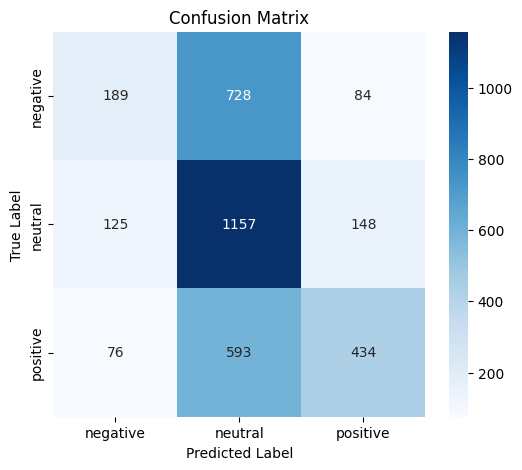

In [23]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.67


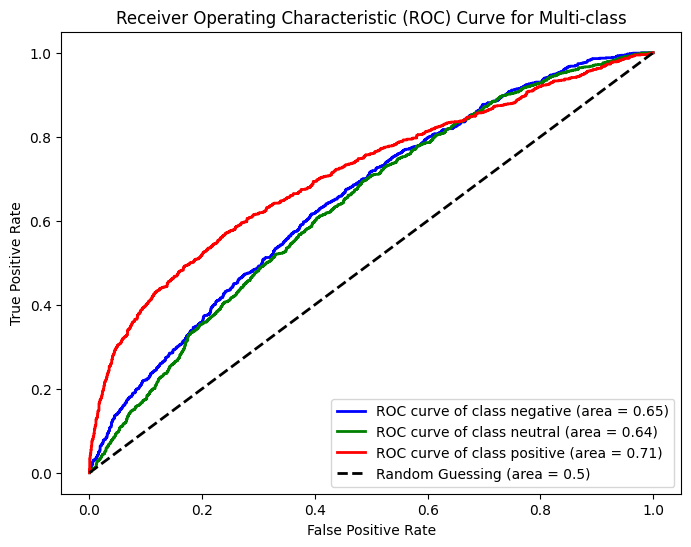

In [24]:
plot_roc_auc(all_labels, all_proba)

## Using Bi-Directional GRU Model

In [25]:
class SentimentGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5, leaky_relu_slope=0.1):
        super(SentimentGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, 
                          bidirectional=True, dropout=dropout_rate if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size * 2, output_size)  # Output size is doubled because of bidirectionality
    
    def forward(self, x):
        # Initialize hidden state
        h0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # Forward propagate the GRU
        out, _ = self.gru(x, h0)
        # Apply Leaky ReLU activation
        # out = nn.functional.leaky_relu(out)
        # Apply dropout
        out = self.dropout(out)
        # Use only the last output for the fully connected layer
        out = self.fc(out[:, -1, :])
        # Apply sigmoid to the output layer
        return out

In [26]:
# Initialize model, loss function, and optimizer
model = SentimentGRU(input_size, hidden_size, output_size, num_layers, dropout_rate, leaky_relu_slope)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch 1/30, Loss: 0.9701, Val Loss: 0.9097
Epoch 2/30, Loss: 0.8920, Val Loss: 0.8718
Epoch 3/30, Loss: 0.8610, Val Loss: 0.8386
Epoch 4/30, Loss: 0.8377, Val Loss: 0.8085
Epoch 5/30, Loss: 0.8242, Val Loss: 0.8006
Epoch 6/30, Loss: 0.8089, Val Loss: 0.7978
Epoch 7/30, Loss: 0.7974, Val Loss: 0.7901
Epoch 8/30, Loss: 0.7837, Val Loss: 0.7920
Epoch 9/30, Loss: 0.7713, Val Loss: 0.7999
Epoch 10/30, Loss: 0.7618, Val Loss: 0.7710
Epoch 11/30, Loss: 0.7508, Val Loss: 0.7657
Epoch 12/30, Loss: 0.7430, Val Loss: 0.7854
Epoch 13/30, Loss: 0.7273, Val Loss: 0.7854
Epoch 14/30, Loss: 0.7134, Val Loss: 0.7847
Early stopped at 14
Lowest Validation Loss: 0.7657 at Epoch 11


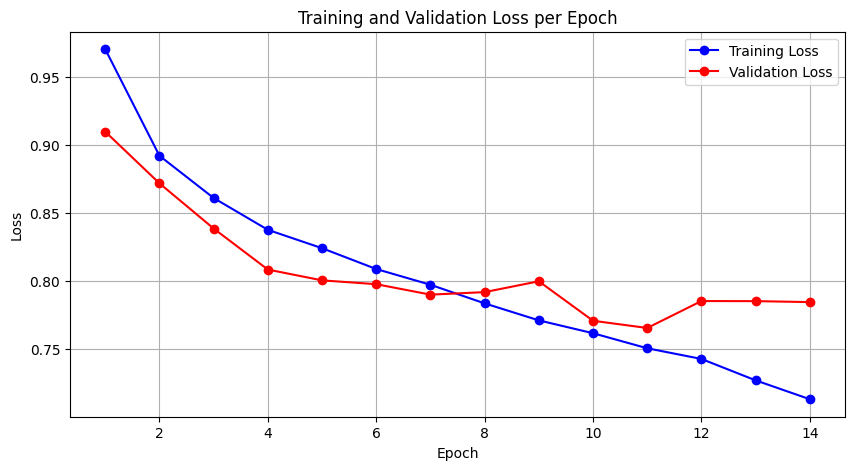

In [ ]:
#Training loop

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 3  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_gru_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [29]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_gru_best_model.pth'))

all_labels, all_preds, all_proba = compute_outputs()

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.6485568760611206,
 'precision': 0.6575352171409646,
 'recall': 0.6485568760611206,
 'f1': 0.6503711467851966}

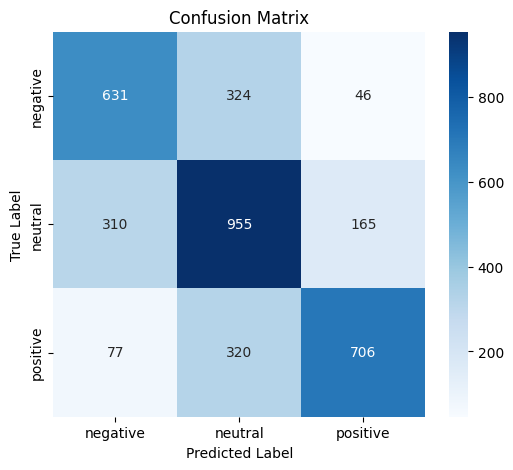

In [30]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.82


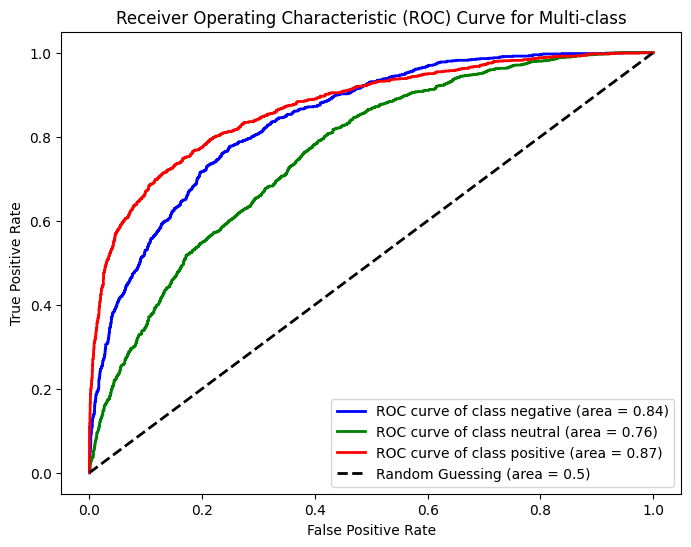

In [31]:
plot_roc_auc(all_labels, all_proba)

## Bidirectional LSTM Model

In [32]:
class SentimentLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers, dropout_rate=0.5, leaky_relu_slope=0.1):
        super(SentimentLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.leaky_relu_slope = leaky_relu_slope

        # # Create LSTM layers with nn.LSTM

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        
        # Define dropout layer
        self.dropout = nn.Dropout(dropout_rate)

        # Fully connected layer (output size is doubled for bidirectionality)
        self.fc = nn.Linear(hidden_size * 2, output_size)


    def forward(self, x):
        h_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c_0 = torch.zeros(2 * self.num_layers, x.size(0), self.hidden_size).to(x.device)

        outputs, _ = self.lstm(x, (h_0, c_0))
        
        # Apply dropout and fully connected layer
        outputs = self.dropout(outputs)
        
        out = self.fc(outputs[:, -1, :])

        return out


In [33]:
# Initialize model, loss function, and optimizer
model = SentimentLSTM(input_size, hidden_size, output_size, num_layers, dropout_rate, leaky_relu_slope)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [34]:
#Training loop

num_epochs = 30  # Number of epochs
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0
max_patience = 5  # Maximum epochs to wait for improvement

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    total_loss = 0
    total_val_loss = 0
    count = 0
    val_count = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        outputs = outputs.squeeze()
        loss = criterion(outputs, labels.long())
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        count += 1
    average_loss = total_loss / count
    losses.append(average_loss)

    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            val_outputs = val_outputs.squeeze()
            val_loss = criterion(val_outputs, labels.long())
            total_val_loss += val_loss.item()
            val_count += 1
    average_val_loss = total_val_loss / val_count
    val_losses.append(average_val_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}')
    
    # Check if the current validation loss is the lowest; if so, save the model
    if average_val_loss < best_val_loss:
        best_val_loss = average_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'bi_lstm_best_model.pth')  # Save the best model
        patience = 0   
    else:
        patience += 1

    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 1/30, Loss: 0.9919, Val Loss: 0.9436
Epoch 2/30, Loss: 0.9108, Val Loss: 0.8871
Epoch 3/30, Loss: 0.8758, Val Loss: 0.8515
Epoch 4/30, Loss: 0.8513, Val Loss: 0.8258
Epoch 5/30, Loss: 0.8305, Val Loss: 0.8192
Epoch 6/30, Loss: 0.8219, Val Loss: 0.8013
Epoch 7/30, Loss: 0.8083, Val Loss: 0.7867
Epoch 8/30, Loss: 0.7947, Val Loss: 0.8205
Epoch 9/30, Loss: 0.7871, Val Loss: 0.7919
Epoch 10/30, Loss: 0.7767, Val Loss: 0.7953
Epoch 11/30, Loss: 0.7669, Val Loss: 0.7788
Epoch 12/30, Loss: 0.7585, Val Loss: 0.7662
Epoch 13/30, Loss: 0.7457, Val Loss: 0.7711
Epoch 14/30, Loss: 0.7344, Val Loss: 0.7650
Epoch 15/30, Loss: 0.7222, Val Loss: 0.7794
Epoch 16/30, Loss: 0.7119, Val Loss: 0.7701
Epoch 17/30, Loss: 0.7012, Val Loss: 0.7656
Epoch 18/30, Loss: 0.6881, Val Loss: 0.7756
Epoch 19/30, Loss: 0.6709, Val Loss: 0.7886
Early stopped at 19
Lowest Validation Loss: 0.7650 at Epoch 14


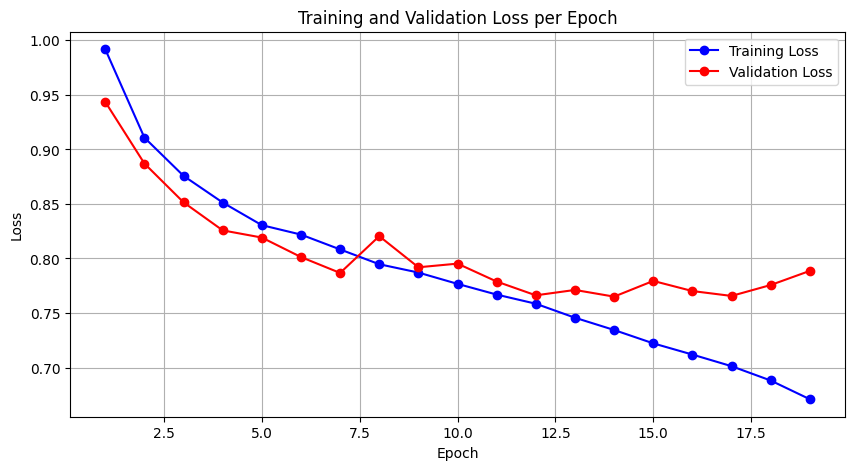

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [36]:
# Load the best model and calculate accuracy only for that
model.load_state_dict(torch.load('bi_lstm_best_model.pth'))

all_labels, all_preds, all_proba = compute_outputs()

metrics = compute_metrics_from_preds(all_labels, all_preds)

metrics

{'accuracy': 0.6604414261460102,
 'precision': 0.668863137287922,
 'recall': 0.6604414261460102,
 'f1': 0.6617058173010267}

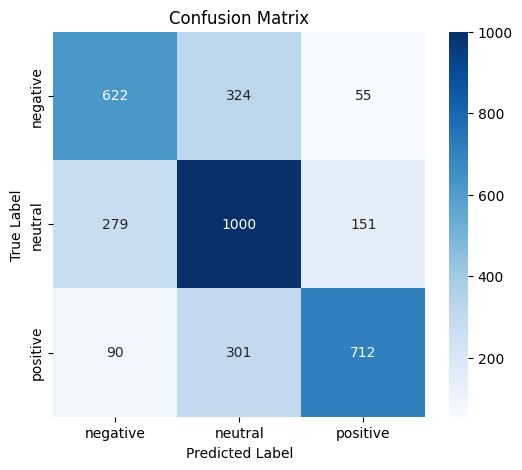

In [38]:
plot_conf_matrix(all_labels, all_preds)

Macro-averaged One-vs-Rest ROC AUC score: 0.83


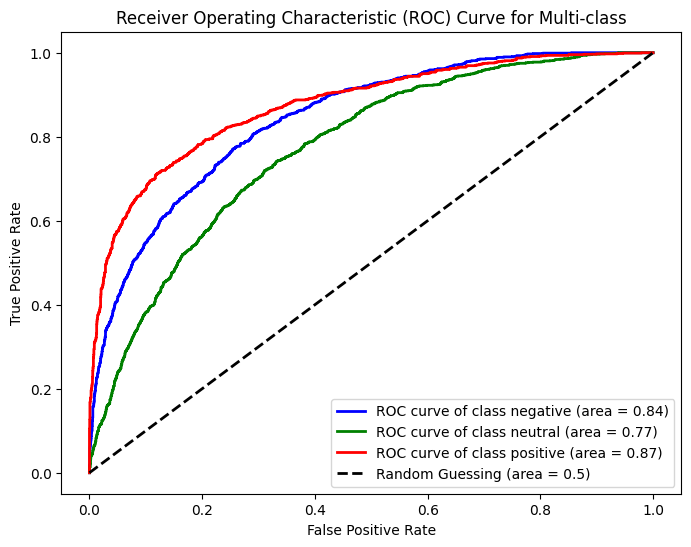

In [39]:
plot_roc_auc(all_labels, all_proba)

## Comparative Study

Put a table / do confusion matrix

| Model | Val Loss | Val Acc | ROC AUC |
| - | - | - | - |
| RNN  | 0.  | 0.  | Use OvR (One versus Rest)  |